Seçilen oteller: ['AnkAkyaka Apart Hotel' 'Panamara Otel' 'Panamare Apart & Hotel Akyaka'
 'Kerme Ottoman Gökova' 'Erdem Otel']
TF-IDF Matrisi Boyutu: (50, 724)
PCA açıklanan varyans oranları: [0.03910488 0.03553318]


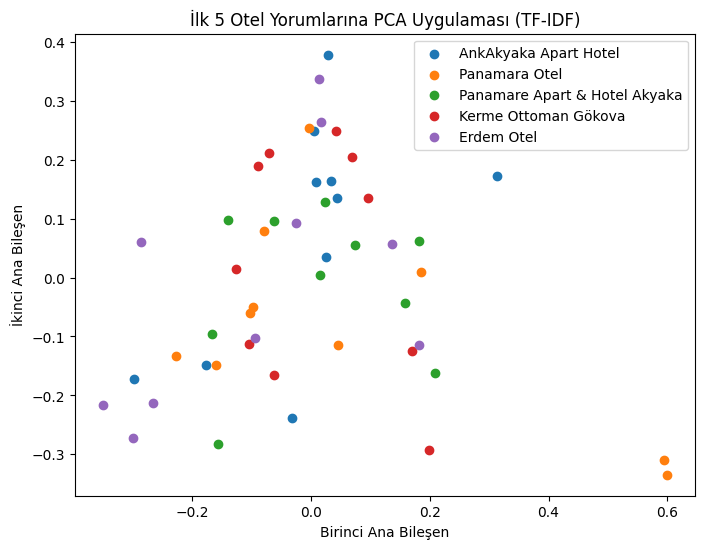

Count Matrisi Boyutu: (50, 724)

LDA ile çıkan konular:
Topic 0:
room place stay hotel thank everything nice clean night location
Topic 1:
room staff stay make business see akyaka customer towel really
Topic 2:
hotel room akyaka holiday want clean time nice pool price
Topic 3:
stay room nice not shower would comfortable tradesman learn clean
Topic 4:
room say hotel stay place clean day price come comment


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA, LatentDirichletAllocation

csv_path = "C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv"
df = pd.read_csv(csv_path, engine="python", encoding="utf-8-sig")

# İlk 5 otel
hotels = df['hotel_name'].unique()[:5]
print("Seçilen oteller:", hotels)

# Bu otellere ait veriyi filtreleyelim
df_subset = df[df['hotel_name'].isin(hotels)]
# İşlenecek yorumlar (boş değerler boş string ile dolduruluyor)
reviews = df_subset['processed_final_review'].fillna("").tolist()
# Her yorumun ait olduğu otel (label)
labels = df_subset['hotel_name'].tolist()

#############################################
# 1. PCA ile Boyut İndirgeme (TF-IDF)
#############################################
# TF-IDF vektörleştirici ile yorumların numerik temsili (sparse matrix) oluşturuluyor.
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(reviews)
print("TF-IDF Matrisi Boyutu:", tfidf_matrix.shape)

# PCA ile 2 boyuta indirgeme (visualization için)
pca = PCA(n_components=2)
# PCA, yoğun (dense) matrisi istediğinden toarray() ile dönüştürüyoruz.
pca_result = pca.fit_transform(tfidf_matrix.toarray())
print("PCA açıklanan varyans oranları:", pca.explained_variance_ratio_)

# PCA sonuçlarını otel etiketlerine göre renkleyerek scatter plot çizelim
plt.figure(figsize=(8,6))
for hotel in hotels:
    indices = [i for i, label in enumerate(labels) if label == hotel]
    plt.scatter(pca_result[indices, 0], pca_result[indices, 1], label=hotel)
plt.xlabel("Birinci Ana Bileşen")
plt.ylabel("İkinci Ana Bileşen")
plt.title("İlk 5 Otel Yorumlarına PCA Uygulaması (TF-IDF)")
plt.legend()
plt.show()

#############################################
# 2. LDA ile Konu Modellemesi (Count Vectorizer)
#############################################
# LDA için CountVectorizer kullanarak kelime sayısına dayalı BoW matrisi oluşturuyoruz.
count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(reviews)
print("Count Matrisi Boyutu:", count_matrix.shape)

# LDA modelini 5 konu (topic) çıkarmak üzere eğitiyoruz
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(count_matrix)

# Her konunun en belirgin 10 kelimesini gösteren yardımcı fonksiyon
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
        
no_top_words = 10
print("\nLDA ile çıkan konular:")
display_topics(lda, count_vectorizer.get_feature_names_out(), no_top_words)


Temizleme işlemi öncesi token frekansları:
room: 1370
hotel: 1106
place: 656
clean: 564
breakfast: 496
stayed: 462
location: 434
stay: 391
akyaka: 336
nice: 333
night: 291
thank: 280
would: 280
friendly: 278
day: 277
recommend: 274
good: 273
family: 266
price: 263
staff: 257
apartment: 257
pool: 242
beautiful: 241
beach: 228
said: 220
like: 217
sea: 214
owner: 200
go: 199
people: 188
holiday: 185
bed: 178
comfortable: 172
great: 170
time: 170
service: 167
definitely: 167
one: 166
close: 165
business: 164
could: 160
apart: 160
view: 160
came: 155
small: 153
everything: 151
water: 150
satisfied: 149
want: 147
say: 146
problem: 145
bathroom: 144
air: 141
went: 137
without: 136
distance: 133
shower: 133
walking: 132
need: 131
really: 130
home: 130
center: 130
made: 128
conditioner: 126
thanks: 125
restaurant: 125
car: 125
balcony: 122
kitchen: 119
also: 119
house: 117
next: 116
garden: 114
see: 113
parking: 113
employee: 112
cleanliness: 112
think: 111
floor: 107
enough: 106
even: 102
left

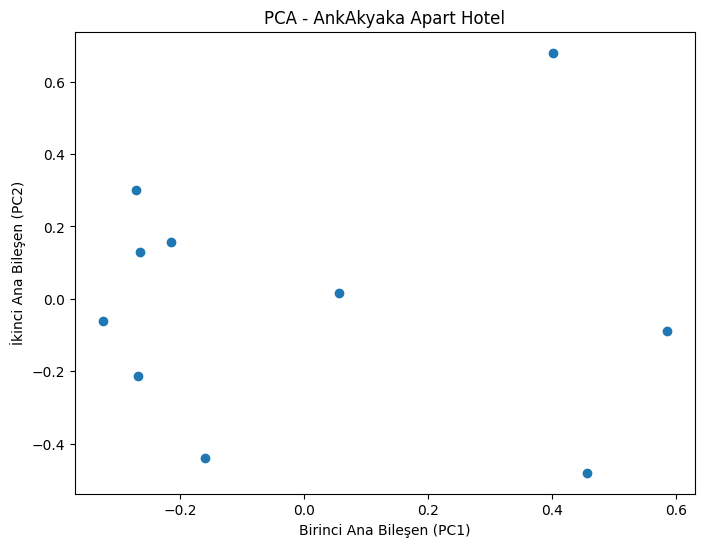

PCA açıklanan varyans oranları: [0.12883215 0.12511113]

LDA ile çıkan konular:
Topic 0:
satisfied apartment decent immaculate accommodation greeting fethiye thoughtful employee thank
Topic 1:
the room you we night a for is price in
Topic 2:
room stay ankakyaka nice use double need balcony really small

--------------------------------------------------

=== Panamara Otel ===
TF-IDF Matrisi Boyutu: (10, 135)


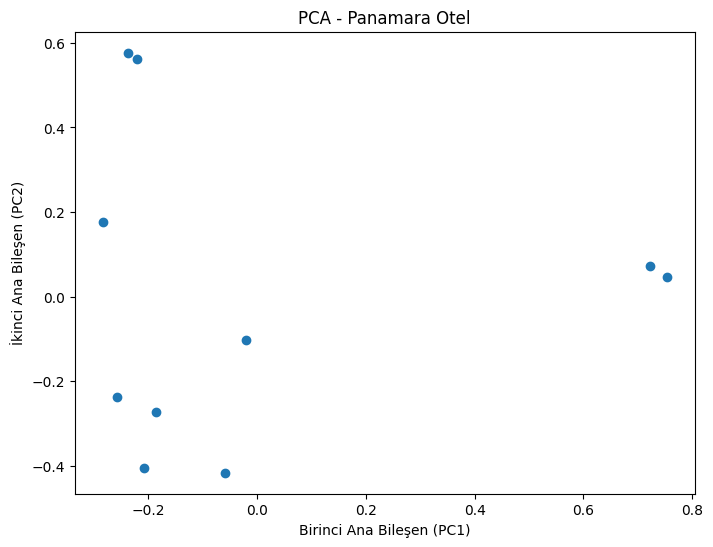

PCA açıklanan varyans oranları: [0.1665915 0.1364728]

LDA ile çıkan konular:
Topic 0:
hotel friendly staff stayed comfortable reach ask balcony olive tree
Topic 1:
stay room night conditioner air think cigarette learn tradesman nice
Topic 2:
enjoyed thanks friendly received well welcoming visitor thank stay nature

--------------------------------------------------

=== Panamare Apart & Hotel Akyaka ===
TF-IDF Matrisi Boyutu: (10, 408)


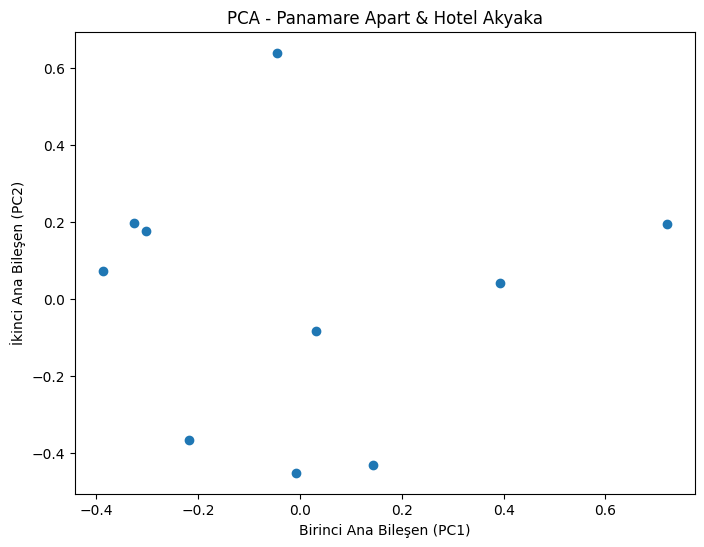

PCA açıklanan varyans oranları: [0.12931828 0.12479919]

LDA ile çıkan konular:
Topic 0:
room hotel day clean staff need coming lady elif said
Topic 1:
business room customer shower towel comment see broken bathroom make
Topic 2:
place system entrance said took hotel pool small make parking

--------------------------------------------------

=== Kerme Ottoman Gökova ===
TF-IDF Matrisi Boyutu: (10, 197)


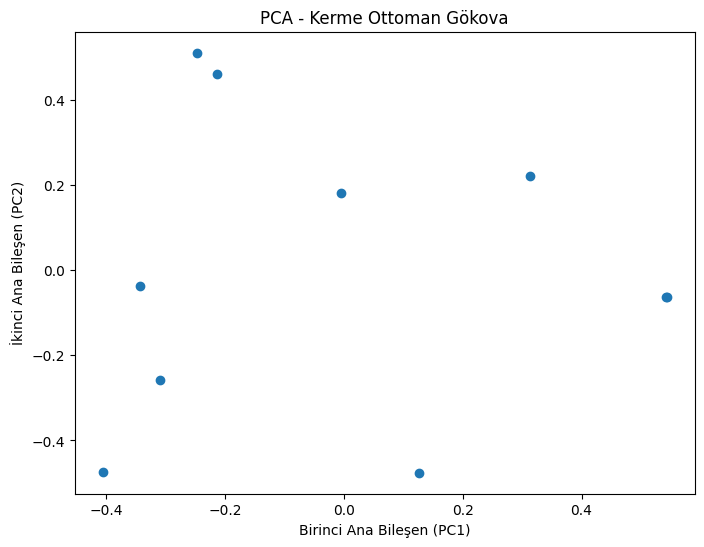

PCA açıklanan varyans oranları: [0.13837438 0.12601525]

LDA ile çıkan konular:
Topic 0:
hotel nice want water affordable sheet choice owner paid child
Topic 1:
hotel family room village night stay akyaka minute pool stayed
Topic 2:
zero shower place price hard small room stay would never

--------------------------------------------------

=== Erdem Otel ===
TF-IDF Matrisi Boyutu: (10, 180)


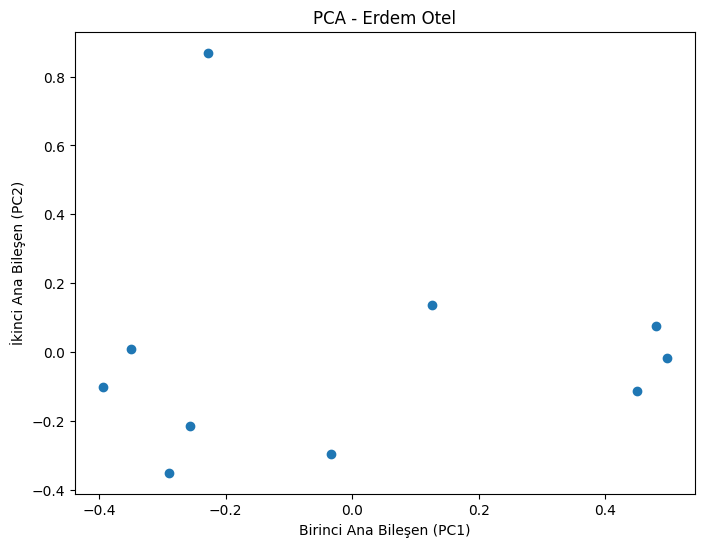

PCA açıklanan varyans oranları: [0.14214806 0.12847355]

LDA ile çıkan konular:
Topic 0:
hotel akyaka holiday room nice pool stay definitely clean friendly
Topic 1:
place find tried everything stayed water help super price market
Topic 2:
room place stayed hotel family thanks close location went quilt

--------------------------------------------------

Bag-of-Words Matrisi (dense array):
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

BoW Vocabulary:
[('abak', 0), ('abi', 1), ('able', 2), ('abnormal', 3), ('abroad', 4), ('absolute', 5), ('absolutely', 6), ('absurd', 7), ('abundance', 8), ('abundant', 9), ('acar', 10), ('accent', 11), ('accept', 12), ('acceptable', 13), ('access', 14), ('accessibility', 15), ('accessible', 16), ('accidentally', 17), ('accommodate', 18), ('accommodation', 19), ('accomodating', 20), ('accompanied', 21), ('accompany', 22), ('accord', 23), ('accordance', 24), ('accordingly', 25), ('ac

NameError: name 'WordCloud' is not defined

In [2]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA, LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
import re

# Gerekli NLTK verilerini indiriyoruz (ilk çalıştırmada)
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)

#######################################
# POS etiketlerini WordNet etiketlerine çeviren yardımcı fonksiyon
#######################################
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

#######################################
# Contraction (kısaltma) genişletme
#######################################
contraction_mapping = {
    "cant": "can not",
    "didnt": "did not",
    "dont": "do not",
    "doesnt": "does not",
    "wont": "will not",
    "wouldnt": "would not",
    "shouldnt": "should not",
    "couldnt": "could not",
    "isnt": "is not",
    "arent": "are not",
    "wasnt": "was not",
    "werent": "were not",
    "im": "i am",
    "ive": "i have",
    "id": "i would",
    "youre": "you are",
    "youve": "you have",
    "hes": "he is",
    "shes": "she is",
    "its": "it is",
    "theyre": "they are",
    "omer": "ömer",
    "ran": "run",
    "theyve": "they have",
    "checkin": "check in",
    "checkout": "check out",
    "superrrrrrrrr": "super",
    "supper": "super",
    "apt": "apartment",
    "ac": "air condition",
    "veey": "very",
    "tzatziki": "cacık",
    "wc": "toilet",
    "ok": "okey",
    "acasya": "akasya",
    "beautıful": "beautiful",
    "anil": "anıl",
    "slept": "sleep",
    "childrens": "children",
    "absolu": "absolutely",
    "mugla": "muğla",
    "oludeniz": "ölüdeniz",
    "saklıkoy": "saklıköy",
    "niceeee": "nice",
    "relaxed": "relax",
    "thanks": "thank",
    "abis": "abi",
    "accommoda": "accomodation"
    # İhtiyaç duyarsanız diğer kısaltmaları ekleyin.
}

def expand_contractions(text):
    for contraction, expansion in contraction_mapping.items():
        pattern = r'\b' + re.escape(contraction) + r'\b'
        text = re.sub(pattern, expansion, text)
    return text

#######################################
# Korumalı İfadeler (protected expressions) – Birleştirilmek istenen kalıp ifadeler
#######################################
protected_expressions = {
    "wellmaintained": "well maintained",
    "warmblooded": "warm blooded",
    "priceperformance": "price performance",
    "fulllength": "full length",
    "turkishstyle": "turkish style",
    "wellintentioned": "well intentioned",
    "wellequiped": "well equiped",
    "sugarfree": "sugar free",
    "glutenfree": "gluten free",
    "brotherinlaw": "brother in law",
    "courtyardgarden": "courtyard garden",
    "roadtrip": "road trip",
    "selfcatering": "self catering",
    "selfrespect": "self respect",
    "roomsized": "room size",
    "settop": "set top",
    "roomspecific": "room specific",
    "homelike": "home like",
    "nicelooking": "nice looking",
    "dungeonlike": "dungeon like",
    "natureloving": "nature loving",
    "wholeheartedly": "whole heartedly",
    "childfriendly": "child friendly",
    "animalfriendly": "animal friendly",
    "familyfriendly": "family friendly",
    "wellappointed": "well appointed",
    "bedtime": "bed time",
    "warmhearted": "warm hearted",
    "air conditioner": "air condition",
    "cacık": "cacık",
    "all inclusive": "all inclusive",
    "overcrowded": "overcrowded",
    "parking lot": "parking lot",
    "sigara böreği": "sigara böreği",
    "ozgem": "özgem",
    "oren": "ören",
    "scar": "scared",
    "yoğurtlama": "yoğurtlama",
    "mantı": "mantı",
    "sorbet": "şerbet",
    "mucver": "mücver",
    "yogurt": "yoğurt",
    "sarıyer börekçisi": "sarıyer börekçisi",
    "kokoreç": "kokoreç"
    # İhtiyaç duyarsanız diğer ifadeleri ekleyin.
}

def protect_expressions(text):
    for phrase, replacement in protected_expressions.items():
        text = re.sub(re.escape(phrase), replacement, text, flags=re.IGNORECASE)
    return text

#######################################
# Metin Temizleme, Normalize Etme, Stopword Çıkarma, Lemmatizasyon
#######################################
def normalize_text(text):
    text = text.casefold()
    text = protect_expressions(text)
    tokens = re.findall(r'[a-zçğıöşü]+', text)
    return " ".join(tokens)

def remove_stopwords(text, lang="english"):
    stop_words = set(stopwords.words(lang))
    for w in ["not", "with", "worst"]:
        stop_words.discard(w)
    extra_stopwords_eng = {
        "km", "going", "u", "eg", "ey", "el", "m", "et", "te", "en", "th", "cm", "b", "bm",
        "dak", "im", "r", "month", "liter", "lira", "fp", "gor", "fk", "gezenkali",
        "minu", "today", "yayoz", "friday", "karcan", "google", "höt", "year", "old", "minutes",
        "18mpbs", "us", "lets", "come", "theres", "min", "ms", "mr", "yes", "11pm",
        "2am", "10pm", "id", "etc", "motors", "tl", "3rd", "its", "etc"
    }
    stop_words.update(extra_stopwords_eng)
    tokens = text.split()
    filtered_tokens = [token for token in tokens if token not in stop_words]
    return " ".join(filtered_tokens)

def lemmatize_text(text):
    lemmatizer = WordNetLemmatizer()
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    lemmatized = [lemmatizer.lemmatize(token, pos=get_wordnet_pos(pos)) for token, pos in pos_tags]
    return " ".join(lemmatized)

#######################################
# Türkçe yer (konum) eklerini kaldırma (yalnızca belirli özel isimlere uygulanacak)
#######################################
known_locations = {"fethiye", "muğla", "akyaka", "ölüdeniz", "aksak"}

def remove_turkish_locative_suffix(word):
    word_lower = word.lower()
    for loc in known_locations:
        pattern = re.compile(r"^(" + re.escape(loc) + r")(daki|deki|dakı|ya|da|de|ta|te)$")
        match = pattern.match(word_lower)
        if match:
            return match.group(1)
    return word

def remove_locative_suffixes(text):
    tokens = text.split()
    new_tokens = [remove_turkish_locative_suffix(token) for token in tokens]
    return " ".join(new_tokens)

#######################################
# CSV Dosyasından Veri Okuma ve Ön İşleme
#######################################
csv_path = "C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv"
df = pd.read_csv(csv_path, engine="python", encoding="utf-8")
df.dropna(subset=["hotel_name", "processed_review"], inplace=True)

reviews = df["processed_review"].fillna("").tolist()
# --- Temizleme işlemleri öncesi token frekanslarını görelim:
pre_clean_tokens = []
for review in reviews:
    temp = review.casefold()
    tokens = re.findall(r'[a-zçğıöşü]+', temp)
    pre_clean_tokens.extend(tokens)
print("Temizleme işlemi öncesi token frekansları:")
for word, count in Counter(pre_clean_tokens).most_common():
    print(f"{word}: {count}")
print("\n------------------------------------\n")

# Adım 1: Yorumları temizleme işlemleri
clean_reviews = [normalize_text(review) for review in reviews]
expanded_reviews = [expand_contractions(review) for review in clean_reviews]
reduced_reviews = [remove_stopwords(review) for review in expanded_reviews]
processed_reviews = [lemmatize_text(review) for review in reduced_reviews]
final_reviews = [remove_locative_suffixes(review) for review in processed_reviews]

print("İlk işlenmiş yorum örneği:")
print(final_reviews[0])
print("\n------------------------------------\n")

# Temizleme sonrası token frekansları:
post_clean_tokens = []
for review in final_reviews:
    post_clean_tokens.extend(review.split())
print("Temizleme işlemi sonrası token frekansları:")
for word, count in Counter(post_clean_tokens).most_common():
    print(f"{word}: {count}")
print("\n------------------------------------\n")

#######################################
# Adım 3: Her Otel İçin Ayrı PCA ve LDA Uygulaması (İlk 5 Otel)
#######################################
# İlk 5 oteli seçelim
first5_hotels = df["hotel_name"].unique()[:5]

# PCA ve LDA için sonuçları saklamak adına boş listeler oluşturuyoruz
pca_results = {}
lda_results = {}

for hotel in first5_hotels:
    print(f"=== {hotel} ===")
    # Otel yorumlarını alıyoruz
    hotel_reviews = df[df["hotel_name"] == hotel]["processed_review"].fillna("").tolist()
    if len(hotel_reviews) == 0:
        print("Bu otel için yorum yok.")
        continue
    
    # --- PCA için TF-IDF Uygulaması ---
    tfidf_vectorizer = TfidfVectorizer(token_pattern=r'\S+')
    X_tfidf = tfidf_vectorizer.fit_transform(hotel_reviews)
    print("TF-IDF Matrisi Boyutu:", X_tfidf.shape)
    
    if X_tfidf.shape[0] < 2:
        print("Yeterli yorum olmadığı için PCA uygulanamıyor.")
    else:
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X_tfidf.toarray())
        pca_results[hotel] = X_pca
        # PCA grafiğini çizdiriyoruz
        plt.figure(figsize=(8, 6))
        plt.scatter(X_pca[:, 0], X_pca[:, 1])
        plt.title(f"PCA - {hotel}")
        plt.xlabel("Birinci Ana Bileşen (PC1)")
        plt.ylabel("İkinci Ana Bileşen (PC2)")
        plt.show()
        print("PCA açıklanan varyans oranları:", pca.explained_variance_ratio_)
    
    # --- LDA için Count Vektörleştirici Uygulaması ---
    count_vectorizer = CountVectorizer(token_pattern=r'\S+')
    X_count = count_vectorizer.fit_transform(hotel_reviews)
    # Konu sayısını otel yorum sayısına bağlı olarak belirleyelim (örneğin 3 konu)
    n_topics = 3 if X_count.shape[0] >= 3 else 1
    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda.fit(X_count)
    feature_names = count_vectorizer.get_feature_names_out()
    n_top_words = 10
    print("\nLDA ile çıkan konular:")
    for topic_idx, topic in enumerate(lda.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))
    print("\n" + "-"*50 + "\n")

#######################################
# Adım 4: Belge Temsili - BoW ve TF-IDF (Global)
#######################################
bow_vectorizer = CountVectorizer(token_pattern=r'\S+')
bow_matrix = bow_vectorizer.fit_transform(final_reviews)
print("Bag-of-Words Matrisi (dense array):")
print(bow_matrix.toarray())
vocab = sorted(bow_vectorizer.vocabulary_.items(), key=lambda x: x[1])
print("\nBoW Vocabulary:")
print(vocab)

tfidf_vectorizer = TfidfVectorizer(token_pattern=r'\S+')
tfidf_matrix = tfidf_vectorizer.fit_transform(final_reviews)
print("\nTF-IDF Matrisi (dense array):")
print(tfidf_matrix.toarray())

print("Matris Boyutu:", bow_matrix.shape)
print("İlk 5 satır:")
print(bow_matrix.toarray()[:5])

#######################################
# Adım 5: Word Cloud ve Zipf's Law Analizi
#######################################
combined_text = " ".join(final_reviews)
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(combined_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Genel Word Cloud (Tüm Yorumlar)")
plt.show()

def plot_zipf(frequencies, title="Zipf's Law", output_path=None):
    sorted_freq = frequencies.most_common()
    ranks = np.arange(1, len(sorted_freq) + 1)
    freq_values = np.array([freq for _, freq in sorted_freq])
    
    def zipf_law(rank, C, s):
        return C / (rank ** s)
    
    popt, _ = curve_fit(zipf_law, ranks, freq_values, maxfev=10000)
    C, s = popt

    plt.figure(figsize=(10, 6))
    plt.loglog(ranks, freq_values, marker=".", linestyle="none", label="Data")
    plt.loglog(ranks, zipf_law(ranks, *popt), label=f"Fitted curve: C = {C:.2f}, s = {s:.2f}")
    plt.title(title)
    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.legend()
    plt.grid(True)
    if output_path:
        plt.savefig(output_path)
    plt.show()
    print(f"Fitted equation: f(r) = {C:.2f} / r^{s:.2f}")

all_tokens = combined_text.split()
all_freq = Counter(all_tokens)
plot_zipf(all_freq, title="Zipf's Law: Tüm Yorumlar")

print("\nTüm işlemler başarıyla tamamlandı!")

#######################################
# Adım 6: İşlenmiş Yorumları CSV'ye Kaydetme (Türkçe karakter bozulmasın)
#######################################
df["processed_final_review"] = final_reviews
output_csv_path = "C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv"
df.to_csv(output_csv_path, index=False, encoding="utf-8-sig")
print("İşlenmiş yorumlar 'processed_final_review' sütunu olarak CSV dosyasına kaydedildi!")


=== AnkAkyaka Apart Hotel ===
AnkAkyaka Apart Hotel için yorum sayısı: 10
TF-IDF Matrisi Boyutu: (10, 228)
PCA açıklanan varyans oranları: [0.14285302 0.12456621]

PCA Bileşeni 0 için en baskın 8 terim:
  room                 weight=-0.2994
  decent               weight=0.2535
  apartment            weight=0.2520
  small                weight=-0.2430
  night                weight=-0.1907
  satisfy              weight=0.1835
  stay                 weight=-0.1667
  need                 weight=0.1593

PCA Bileşeni 1 için en baskın 8 terim:
  price                weight=0.3008
  nice                 weight=-0.1930
  low                  weight=0.1929
  disturb              weight=0.1929
  stay                 weight=-0.1655
  balcony              weight=-0.1560
  place                weight=-0.1377
  akyaka               weight=0.1369


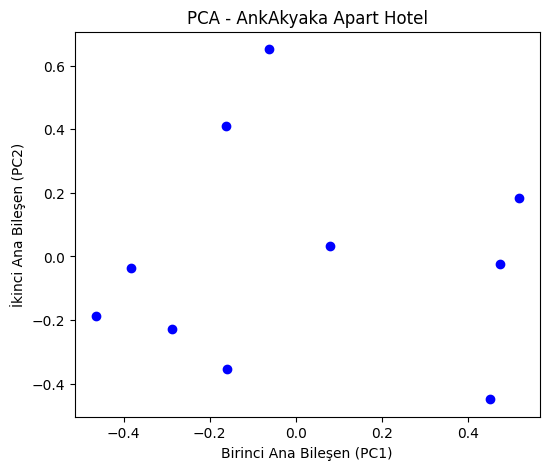


LDA ile çıkan konular:

Topic 0:
price room experience staff hotel clean location style

Topic 1:
room stay apartment immaculate thank satisfy small balcony

Topic 2:
room stay night really nice need small ankakyaka

--------------------------------------------------

=== Panamara Otel ===
Panamara Otel için yorum sayısı: 10
TF-IDF Matrisi Boyutu: (10, 129)
PCA açıklanan varyans oranları: [0.17142098 0.1332524 ]

PCA Bileşeni 0 için en baskın 8 terim:
  think                weight=0.2853
  cigarette            weight=0.2853
  comment              weight=0.2853
  dust                 weight=0.2144
  visible              weight=0.2144
  filter               weight=0.2144
  smell                weight=0.2135
  thank                weight=-0.1849

PCA Bileşeni 1 için en baskın 8 terim:
  enjoy                weight=-0.3047
  friendly             weight=0.2797
  thank                weight=-0.2719
  stay                 weight=-0.2695
  receive              weight=0.2247
  visitor         

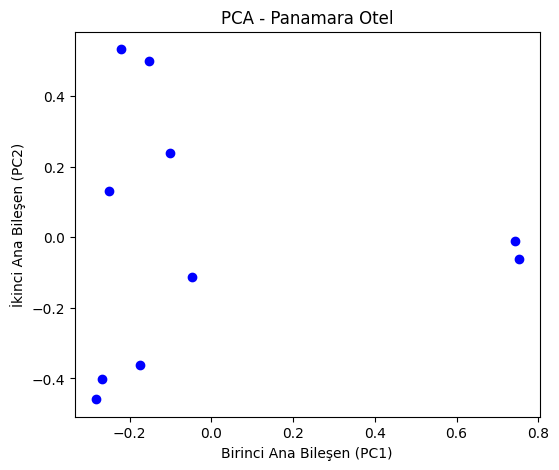


LDA ile çıkan konular:

Topic 0:
stay hotel learn tradesman not night smell price

Topic 1:
nice room air condition stay would least filter

Topic 2:
friendly staff hitchhiker traditional manner furniture worker seasonal

--------------------------------------------------

=== Panamare Apart & Hotel Akyaka ===
Panamare Apart & Hotel Akyaka için yorum sayısı: 10
TF-IDF Matrisi Boyutu: (10, 377)
PCA açıklanan varyans oranları: [0.1313329 0.1271574]

PCA Bileşeni 0 için en baskın 8 terim:
  clean                weight=0.2514
  helpful              weight=0.1987
  beach                weight=0.1987
  distance             weight=0.1987
  walk                 weight=0.1987
  large                weight=0.1987
  modern               weight=0.1842
  perfect              weight=0.1842

PCA Bileşeni 1 için en baskın 8 terim:
  say                  weight=-0.2582
  not                  weight=0.2012
  mom                  weight=0.1784
  together             weight=0.1784
  comfortable          

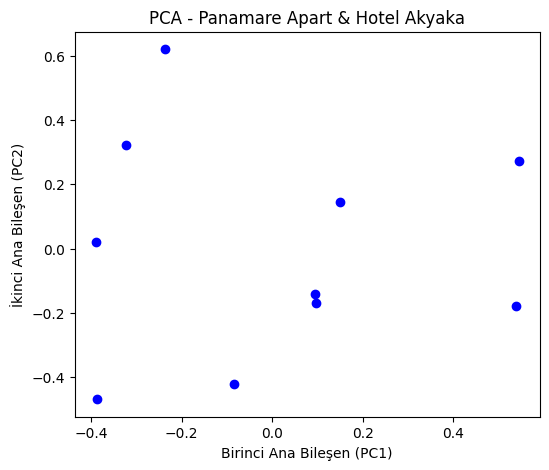


LDA ile çıkan konular:

Topic 0:
business room see stay make towel customer comment

Topic 1:
help staff time make apartment need room come

Topic 2:
say hotel day clean system shower place pool

--------------------------------------------------

=== Kerme Ottoman Gökova ===
Kerme Ottoman Gökova için yorum sayısı: 10
TF-IDF Matrisi Boyutu: (10, 188)
PCA açıklanan varyans oranları: [0.14029558 0.12610702]

PCA Bileşeni 0 için en baskın 8 terim:
  breakfast            weight=0.2873
  hotel                weight=-0.2028
  price                weight=-0.1887
  akyaka               weight=-0.1805
  smell                weight=0.1793
  drinking             weight=0.1793
  poor                 weight=0.1793
  bathroom             weight=0.1793

PCA Bileşeni 1 için en baskın 8 terim:
  family               weight=0.4625
  kid                  weight=0.4328
  suitable             weight=0.4328
  place                weight=-0.1603
  price                weight=-0.1449
  hotel                w

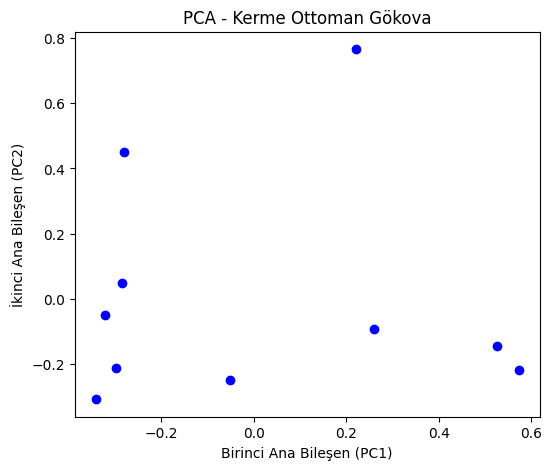


LDA ile çıkan konular:

Topic 0:
hotel price nice want zero shower sheet clean

Topic 1:
breakfast stay bad turkish palace wonderful ottoman traditional

Topic 2:
akyaka hotel stay room time pool village small

--------------------------------------------------

=== Erdem Otel ===
Erdem Otel için yorum sayısı: 10
TF-IDF Matrisi Boyutu: (10, 172)
PCA açıklanan varyans oranları: [0.14397016 0.1288377 ]

PCA Bileşeni 0 için en baskın 8 terim:
  everything           weight=0.2966
  thank                weight=0.2763
  help                 weight=0.2442
  room                 weight=-0.2151
  place                weight=0.2063
  close                weight=0.1990
  try                  weight=0.1980
  find                 weight=0.1561

PCA Bileşeni 1 için en baskın 8 terim:
  hotel                weight=-0.3057
  however              weight=0.2754
  dirty                weight=0.2754
  employee             weight=0.2754
  especially           weight=0.2754
  helpful              weight=0.

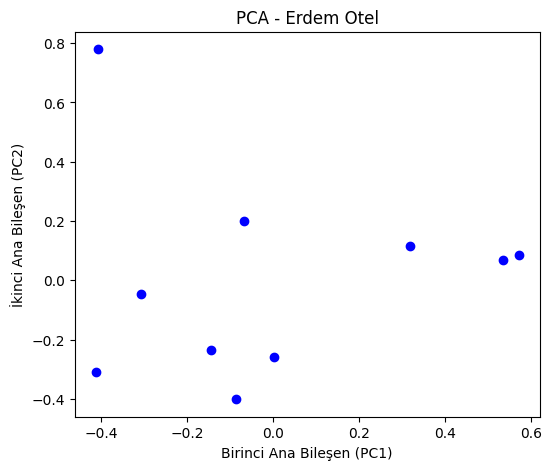


LDA ile çıkan konular:

Topic 0:
room place stay thank everything help go find

Topic 1:
super place stay water clean close nice hot

Topic 2:
hotel room stay staff location place akyaka friendly

--------------------------------------------------



In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA, LatentDirichletAllocation
import matplotlib.pyplot as plt

def print_top_pca_terms(pca_components, feature_names, top_n=8):
    """
    Her PCA bileşeni için en yüksek ağırlığa sahip kelimeleri yazdırır.
    Hem pozitif hem de negatif yönde en baskın kelimeler gösterilebilir.
    """
    for i, comp in enumerate(pca_components):
        print(f"\nPCA Bileşeni {i} için en baskın {top_n} terim:")
        # En büyük mutlak değere sahip terimleri bul
        indices = np.argsort(np.abs(comp))[-top_n:]
        # Bu terimlerin bileşen ağırlıklarını da sıralayalım (büyükten küçüğe)
        sorted_indices = indices[np.argsort(-np.abs(comp[indices]))]
        for idx in sorted_indices:
            term = feature_names[idx]
            weight = comp[idx]
            print(f"  {term:20} weight={weight:.4f}")

def print_lda_topics(lda_model, feature_names, n_top_words=10):
    """
    LDA ile bulunan konuları ve en baskın kelimeleri yazdırır.
    """
    for topic_idx, topic in enumerate(lda_model.components_):
        print(f"\nTopic {topic_idx}:")
        # Kelimeleri önem sırasına göre (büyükten küçüğe) sıralıyoruz
        top_indices = topic.argsort()[::-1][:n_top_words]
        top_terms = [feature_names[i] for i in top_indices]
        print(" ".join(top_terms))

#-------------------------------------------------
# AŞAĞIDAKİ KOD SADECE PCA VE LDA AŞAMALARINI YAPAR
#-------------------------------------------------

# df DataFrame'inde "hotel_name" ve "processed_review" sütunları olduğu varsayılıyor
# (Örnek: df = pd.read_csv("final_processed_reviews.csv", encoding="utf-8"))

def pca_and_lda_for_first5_hotels(df, n_topics=3):
    """
    İlk 5 otelin yorumlarına ayrı ayrı PCA ve LDA uygular.
    :param df: DataFrame - "hotel_name" ve "processed_review" sütunları içermeli.
    :param n_topics: LDA'da bulunacak konu sayısı.
    """
    # İlk 5 oteli seç
    first5_hotels = df["hotel_name"].unique()[:5]
    
    for hotel in first5_hotels:
        print(f"=== {hotel} ===")
        
        # Otelin yorumlarını al
        hotel_reviews = df.loc[df["hotel_name"] == hotel, "processed_final_review"].dropna().tolist()
        print(f"{hotel} için yorum sayısı: {len(hotel_reviews)}")
        
        if len(hotel_reviews) < 2:
            print("Yeterli yorum olmadığı için PCA ve LDA anlamlı sonuç vermeyebilir.\n")
            continue
        
        #--- 1) PCA: TF-IDF ile vektörleştirme ---
        tfidf_vectorizer = TfidfVectorizer(token_pattern=r'\S+')
        X_tfidf = tfidf_vectorizer.fit_transform(hotel_reviews)  # (n_yorum, n_kelime)
        
        print("TF-IDF Matrisi Boyutu:", X_tfidf.shape)
        
        # PCA (2 bileşen)
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X_tfidf.toarray())  # PCA girişi dense array olmalı
        
        # PCA açıklanan varyans
        print("PCA açıklanan varyans oranları:", pca.explained_variance_ratio_)
        
        # PCA en baskın kelimeler (her bileşen için top kelimeler)
        feature_names = tfidf_vectorizer.get_feature_names_out()
        print_top_pca_terms(pca.components_, feature_names, top_n=8)
        
        # PCA 2D Grafiği
        plt.figure(figsize=(6, 5))
        plt.scatter(X_pca[:, 0], X_pca[:, 1], color="blue")
        plt.title(f"PCA - {hotel}")
        plt.xlabel("Birinci Ana Bileşen (PC1)")
        plt.ylabel("İkinci Ana Bileşen (PC2)")
        plt.show()
        
        #--- 2) LDA: CountVectorizer ile vektörleştirme ---
        count_vectorizer = CountVectorizer(token_pattern=r'\S+')
        X_count = count_vectorizer.fit_transform(hotel_reviews)
        
        # LDA modeli
        # (n_topics parametresi yeterli yorum varsa 3 vb., yoksa 1 gibi)
        lda = LatentDirichletAllocation(n_components=min(n_topics, len(hotel_reviews)),
                                        random_state=42)
        lda.fit(X_count)
        
        # LDA konularını yazdır
        count_feature_names = count_vectorizer.get_feature_names_out()
        print("\nLDA ile çıkan konular:")
        print_lda_topics(lda, count_feature_names, n_top_words=8)
        
        print("\n" + "-"*50 + "\n")

#----------------------------------------------
# KULLANIM ÖRNEĞİ
#----------------------------------------------
if __name__ == "__main__":
    # Örnek DataFrame'i okuyalım (temizleme aşamaları HARİÇ, direk "processed_review" kullanıyoruz)
    df = pd.read_csv("C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv", encoding="utf-8")
    
    # Sadece PCA ve LDA
    pca_and_lda_for_first5_hotels(df, n_topics=3)
